# Audio Classification with Audio Spectrogram Transformer (AST)

This notebook combines all project modules into a single workflow:
1. **Data Handling** – reading CSVs, extracting mel-spectrograms, saving/loading features
2. **Dataset Class** – PyTorch `Dataset` for feeding data to the model
3. **Model** – AST-based classifier with a custom MLP head
4. **Training** – training loop with early stopping, LR scheduling, and evaluation

## 1. Imports

In [3]:
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import soundfile as sf
import librosa
import pickle
from torch.utils.data import Dataset, DataLoader
from transformers import ASTModel, ASTFeatureExtractor

C:\Users\Arttu\anaconda3\envs\audion\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Hyperparameters

In [4]:
NUM_CLASSES = 23
BATCH_SIZE = 20
LEARNING_RATE = 1e-3
NUM_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
DROPOUT = 0.3
FREEZE_AST = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Data Handling

Functions for reading CSV metadata, extracting mel-spectrograms, and saving/loading pre-extracted features.

In [5]:
def read_data_from_csv():
    """
    Reads data from csv files and constructs a data structure containing
    file paths and labels for each dataset.
    """
    train_df1 = pd.read_csv("bsdk10k-splits/bsd10k-train.csv")
    val_df = pd.read_csv("bsdk10k-splits/bsd10k-val.csv")
    test_df = pd.read_csv("bsdk10k-splits/bsd10k-test.csv")

    # file paths for 10k dataset audios
    audio_path = Path("audio")
    train_files1 = [f"{audio_path}/{sound_id}.wav" for sound_id in train_df1["sound_id"]]
    val_files = [f"{audio_path}/{sound_id}.wav" for sound_id in val_df["sound_id"]]
    test_files = [f"{audio_path}/{sound_id}.wav" for sound_id in test_df["sound_id"]]

    # labels for 10k dataset audios
    train_labels1 = train_df1["class_idx"].to_list()
    val_labels = val_df["class_idx"].to_list()
    test_labels = test_df["class_idx"].to_list()

    # load 35k audio
    audio_path2 = Path("BSD35k-CS-draft/audio")
    train_df2 = pd.read_csv("BSD35k-CS-draft/metadata/BSD35k-CS-draft-metadata.csv")

    # map 35k labels to the same format as 10k labels
    class_to_id = dict(zip(train_df1["class"], train_df1["class_idx"]))
    train_df2["class_idx"] = train_df2["class"].map(class_to_id)
    train_df2 = train_df2.dropna(subset=["class_idx"])

    train_files2 = [f"{audio_path2}/{sound_id}.wav" for sound_id in train_df2["sound_id"]]
    train_labels2 = train_df2["class_idx"].to_list()

    # concatenate train data
    train_files = train_files1 + train_files2
    train_labels = train_labels1 + train_labels2

    # split train data into half for easier data storing
    middle_idx = int(len(train_labels) // 2)

    train_files1 = train_files[:middle_idx]
    train_labels1 = train_labels[:middle_idx]

    train_files2 = train_files[middle_idx:]
    train_labels2 = train_labels[middle_idx:]

    train_data1 = {"files": train_files1, "labels": train_labels1}
    train_data2 = {"files": train_files2, "labels": train_labels2}
    val_data = {"files": val_files, "labels": val_labels}
    test_data = {"files": test_files, "labels": test_labels}

    return train_data1, train_data2, val_data, test_data


def extract_mel(file):
    """Extract mel-spectrogram from an audio file."""
    y, sr = sf.read(file)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=1024, n_mels=128)
    return S


def save_features(files, labels, split):
    """
    Extracts features and saves them along with labels into a pkl file.

    :param files: list of file paths
    :param labels: list of labels
    :param split: data split (str)
    """
    counter = 0
    features = []
    for file in files:
        counter += 1
        features.append(extract_mel(file))
        if counter % 1000 == 0:
            print(counter)

    data = {"features": features, "labels": labels}

    with open(f"./data/features_and_labels_{split}.pkl", "wb") as f:
        pickle.dump(data, f)


def read_data_from_pkl():
    """Load pre-extracted features from pkl files."""
    with open("features_and_labels_train1.pkl", "rb") as f:
        train_data1 = pickle.load(f)

    with open("features_and_labels_train2.pkl", "rb") as f:
        train_data2 = pickle.load(f)

    with open("features_and_labels_val.pkl", "rb") as f:
        val_data = pickle.load(f)

    with open("features_and_labels_test.pkl", "rb") as f:
        test_data = pickle.load(f)

    return train_data1, train_data2, val_data, test_data

## 4. Model

Audio classifier using the Audio Spectrogram Transformer (AST) as a frozen feature extractor with a custom MLP classification head.

In [6]:
def get_feature_extractor() -> ASTFeatureExtractor:
    """
    Returns the AST feature extractor configured for the pre-trained model.
    Use this to preprocess raw audio waveforms before feeding them to the model.
    """
    return ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")


class AudioClassifier(nn.Module):
    """
    Audio classifier using the Audio Spectrogram Transformer (AST) as a
    frozen feature extractor with a custom MLP classification head.

    The AST model (MIT/ast-finetuned-audioset-10-10-0.4593) converts
    mel-spectrogram inputs into rich audio embeddings. These embeddings
    are then passed through trainable MLP layers for classification.
    """

    def __init__(self, num_classes: int = 23, freeze_ast: bool = True, dropout: float = 0.3):
        """
        :param num_classes: Number of output classes (default 23 for BSD dataset).
        :param freeze_ast: Whether to freeze the AST backbone weights.
        :param dropout: Dropout probability for the MLP head.
        """
        super().__init__()

        # Load pre-trained AST model (without its classification head)
        self.ast = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
        self.hidden_size = self.ast.config.hidden_size  # 768

        # Freeze AST parameters so only the MLP head is trained
        if freeze_ast:
            for param in self.ast.parameters():
                param.requires_grad = False

        # Custom MLP classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, 512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        :param input_values: Mel-spectrogram tensor of shape
            (batch, freq_bins, time_frames) as produced by ASTFeatureExtractor.
        :returns: Logits tensor of shape (batch, num_classes).
        """
        outputs = self.ast(input_values=input_values)

        # Use the [CLS] token embedding (first token) as the audio representation
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch, 768)

        logits = self.classifier(cls_embedding)
        return logits

## 5. Dataset Class

PyTorch `Dataset` that can work with either raw waveforms (applying the AST feature extractor on-the-fly) or pre-extracted mel-spectrograms.

In [7]:
# Fixed time dimension for mel-spectrograms (pad or truncate to this length)
MAX_TIME_FRAMES = 1024


class MyDataset(Dataset):
    """
    Dataset that wraps raw audio waveforms and applies the AST feature
    extractor on-the-fly, returning input_values ready for the AST model.

    Can also accept pre-extracted mel-spectrograms (as numpy arrays) if
    ``use_ast_extractor=False``.
    """

    def __init__(self, features, labels, sampling_rate: int = 16000,
                 use_ast_extractor: bool = True,
                 max_time_frames: int = MAX_TIME_FRAMES):
        """
        :param features: list of 1-D numpy arrays (raw waveforms) or
            pre-extracted mel-spectrograms.
        :param labels: list of integer class labels.
        :param sampling_rate: audio sampling rate (default 16000).
        :param use_ast_extractor: if True, apply AST feature extractor to
            raw waveforms; if False, features are used as-is.
        :param max_time_frames: fixed time dimension to pad/truncate mel
            spectrograms to (only used when use_ast_extractor=False).
        """
        super().__init__()
        self.features = features
        self.labels = labels
        self.sampling_rate = sampling_rate
        self.use_ast_extractor = use_ast_extractor
        self.max_time_frames = max_time_frames

        if self.use_ast_extractor:
            self.feature_extractor = get_feature_extractor()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        feature = self.features[idx]
        label = self.labels[idx]

        if self.use_ast_extractor:
            # feature is a raw waveform (1-D numpy array)
            inputs = self.feature_extractor(
                feature,
                sampling_rate=self.sampling_rate,
                padding="max_length",
                truncation=True,
                max_length=16000 * 10,  # 10 seconds max
                return_tensors="pt",
            )
            feature = inputs["input_values"].squeeze(0)  # (time_frames, freq_bins)
        else:
            # feature is a pre-extracted mel-spectrogram of shape (n_mels, time)
            feature = torch.tensor(np.array(feature), dtype=torch.float32)

            # Pad or truncate along the time axis to fixed length
            time_len = feature.shape[1]
            if time_len < self.max_time_frames:
                # Pad with zeros on the right
                feature = F.pad(feature, (0, self.max_time_frames - time_len))
            elif time_len > self.max_time_frames:
                # Truncate
                feature = feature[:, :self.max_time_frames]

        label = torch.tensor(int(label), dtype=torch.long)
        return feature, label

## 6. Data Loading

Load pre-extracted features from pkl files and create DataLoaders.

In [7]:
def load_data():
    """Load pre-extracted features from pkl files and create DataLoaders."""
    train_data1, train_data2, val_data, test_data = read_data_from_pkl()

    # Merge the two training halves
    train_features = train_data1["features"] + train_data2["features"]
    train_labels = train_data1["labels"] + train_data2["labels"]

    val_features = val_data["features"]
    val_labels = val_data["labels"]

    test_features = test_data["features"]
    test_labels = test_data["labels"]

    # Create datasets (use_ast_extractor=False because features are pre-extracted mel specs)
    train_dataset = MyDataset(train_features, train_labels, use_ast_extractor=False)
    val_dataset = MyDataset(val_features, val_labels, use_ast_extractor=False)
    test_dataset = MyDataset(test_features, test_labels, use_ast_extractor=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    # Free raw data references
    del train_data1, train_data2, val_data, test_data
    del train_features, train_labels, val_features, val_labels, test_features, test_labels
    gc.collect()

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = load_data()
print(f"Train batches: {len(train_loader)}  |  "
      f"Val batches: {len(val_loader)}  |  "
      f"Test batches: {len(test_loader)}")

Train batches: 1850  |  Val batches: 54  |  Test batches: 219


## 7. Training & Validation Loops

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Run evaluation. Returns average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)

        logits = model(features)
        loss = criterion(logits, labels)

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

## 8. Model Initialization

In [9]:
model = AudioClassifier(
    num_classes=NUM_CLASSES,
    freeze_ast=FREEZE_AST,
    dropout=DROPOUT,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

# Loss & Optimiser
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)
# Reduce LR on plateau for better convergence
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3,
)

C:\Users\Arttu\anaconda3\envs\audion\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Arttu\.cache\huggingface\hub\models--MIT--ast-finetuned-audioset-10-10-0.4593. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Trainable parameters: 532,503


## 9. Training Loop

In [ ]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS}  |  "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f}  |  "
        f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
    )

    # Save best model & early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")
        print(f"  ↳ Saved best model (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ↳ No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs.")
            break

## 10. Plot Training Curves

In [ ]:
epochs = range(1, len(train_losses) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs, train_losses, label="Train Loss")
ax1.plot(epochs, val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(epochs, train_accs, label="Train Acc")
ax2.plot(epochs, val_accs, label="Val Acc")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("Saved training curves to training_curves.png")

## 11. Test Evaluation

### 11.1 Config and label mapping

In [8]:
from sklearn.metrics import confusion_matrix

# Config
MODEL_PATH = "best_model.pt"
LAMBDA = 0.5 # = partial credit for same top-level, different second-level


# BST label mapping
# derived from the provided data split .csv files
CLASS_NAMES = [
    "Solo percussion", # 0, m-sp
    "Solo instrument", # 1, m-si
    "Multiple instruments", # 2 m-m
    "Percussion", # 3 is-p
    "String", # 4 is-s
    "Wind", # 5 is-w
    "Piano / Keyboard", # 6 is-k
    "Synths / Electronic", # 7 is-e
    "Solo speech", # 8 sp-s
    "Conversation / Crowd", # 9 sp-c
    "Processed / Synthetic", # 10 sp-p
    "Objects / House appliances", # 11 fx-o
    "Vehicles", # 12 fx-v
    "Other mechanisms / machines", # 13 fx-m
    "Human sounds and actions", # 14 fx-h
    "Animals", # 15 fx-a
    "Natural elements & explosions", # 16 fx-n
    "Experimental", # 17 fx-ex
    "Electronic / Design", # 18 fx-el
    "Nature", # 19 ss-n
    "Indoors", # 20 ss-i
    "Urban", # 21 ss-u
    "Synthetic / Artificial" # 22 ss-s
]

# Short labels for CM
CLASS_KEYS = [
    "m-sp", "m-si", "m-m",
    "is-p", "is-s", "is-w", "is-k", "is-e",
    "sp-s", "sp-c", "sp-p",
    "fx-o", "fx-v", "fx-m", "fx-h", "fx-a", "fx-n", "fx-ex", "fx-el",
    "ss-n", "ss-i", "ss-u", "ss-s",
]

PARENT = {
    0: "Music", 1: "Music", 2: "Music",
    3: "Instrument samples", 4: "Instrument samples", 5: "Instrument samples",
    6: "Instrument samples", 7: "Instrument samples",
    8: "Speech", 9: "Speech", 10: "Speech",
    11: "Sound effects", 12: "Sound effects", 13: "Sound effects",
    14: "Sound effects", 15: "Sound effects", 16: "Sound effects",
    17: "Sound effects", 18: "Sound effects",
    19: "Soundscapes", 20: "Soundscapes", 21: "Soundscapes",
    22: "Soundscapes",
}

GROUP_COLOURS = {
    "Music": "#e05c5c",
    "Instrument samples": "#f0a830",
    "Speech": "#4db8b8",
    "Sound effects": "#5b9bd5",
    "Soundscapes": "#5cb85c",
}


### 11.2 Helper functions (metric computation and plotting)

In [9]:
# Testing data
def load_test_data() -> DataLoader:
    """Loads the test data only. Returns the DataLoader."""
    _, _, _, test_data = read_data_from_pkl()
    dataset = MyDataset(
        test_data["features"], test_data["labels"], use_ast_extractor=False
    )
    return DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# Inference
@torch.no_grad()
def get_predictions(model: nn.Module, loader: DataLoader):
    """Runs inference on a model and returns the predictions."""
    model.eval()
    all_preds, all_labels = [], []
    for features, labels in loader:
        logits = model(features.to(DEVICE))
        all_preds.append(logits.argmax(dim=-1).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)

# Standard metrics
def overall_accuracy(preds, labels) -> float:
    """Computation of overall accuracy."""
    return float((preds == labels). mean())

def per_class_accuracy(preds, labels) -> np.ndarray:
    """Computation of per class accuracy."""
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    return cm.diagonal() / row_sums.squeeze()

# Hierarchical metrics
def _weight(i: int, j: int) -> float:
    """
    Weight w_ij for the hierarchical metric formula:
        w_ij = 1, if i == j
        w_ij = lambda (0.5), if i != j but same top-level parents (partial credit)
        w_ij = 0, otherwise
    """
    if i == j:
        return 1.0
    if PARENT[i] == PARENT[j]:
        return LAMBDA
    return 0.0

def hierarchical_metrics(preds, labels):
    """Computation of hierarchical matrics from project slides."""
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))

    hP_list, hR_list, hF_list = [], [], []

    for i in range(NUM_CLASSES):
        num_P = 0.0 # numerator sum_j(w_ij * TP_ij)
        den_P = 0.0 # denominator sum_j(w_ij * (TP_ij + FP_ij))
        den_R = 0.0 # denominator sum_j(w_ij * (TP_ij + FN_ij))

        for j in range(NUM_CLASSES):
            w = _weight(i, j)
            if w == 0.0:
                continue

            if i == j:
                tp_ij = cm[i, i]
                fp_ij = cm[:, j].sum() - cm[i, j] # others predicted as i
                fn_ij = cm[i, :].sum() - cm[i, i] # truly i but predicted elsewhere
            else:
                # Same parent, off-diagonal: no TP but partial FP/FN
                tp_ij = 0.0
                fp_ij = cm[:, j].sum() - cm[i, j] # predicted j, not truly i
                fn_ij = cm[i, j] # truly i, predicted as j

            num_P += w * tp_ij
            den_P += w * (tp_ij + fp_ij)
            den_R += w * (tp_ij + fn_ij)
        hp_i = num_P / den_P if den_P > 0 else 0.0
        hr_i = num_P / den_R if den_R > 0 else 0.0
        hf_i = (2 * hp_i * hr_i / (hp_i + hr_i)) if (hp_i + hr_i) > 0 else 0.0

        hP_list.append(hp_i)
        hR_list.append(hr_i)
        hF_list.append(hf_i)

    return (
        float(np.mean(hP_list)),
        float(np.mean(hR_list)),
        float(np.mean(hF_list)),
    )

# Plots
def plot_confusion_matrix(preds, labels):
    """Computes and plots the confusion matrix."""
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    cm_norm = cm / row_sums

    fig, ax = plt.subplots(figsize=(14, 12))
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)

    thresh = 0.5
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = cm_norm[i, j]
            if val > 0.01:
                ax.text(j, i, f"{val:.2f}",
                        ha="center", va="center", fontsize=6,
                        color="white" if val>thresh else "black")

    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_KEYS, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(CLASS_KEYS, fontsize=9)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title("Normalized confusion matrix (rows = true class)", fontsize=13)

    plt.tight_layout()
    plt.show()

def plot_per_class_accuracy(pca):
    """Plots a histogram of the per-class accuracy. Colour-coded to match the parent classes."""
    idx = np.argsort(pca)
    accs = pca[idx]
    names = [f"{CLASS_KEYS[i]}" for i in idx]
    bar_colours = [GROUP_COLOURS[PARENT[i]] for i in idx]
    mean = pca.mean()

    x_pos = np.arange(len(names))

    fig, ax = plt.subplots(figsize=(11,9))
    bars = ax.bar(x_pos, accs, color=bar_colours, edgecolor="white")

    ax.set_xticks(x_pos)
    ax.set_xticklabels(names, fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=11)
    ax.set_title(
        "Per-Class Accuracy (sorted ascending)", fontsize=12,
    )
    ax.set_ylim(0, 1.12)
    ax.axhline(mean, color="crimson", linestyle="--", linewidth=1.5)

    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.3f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

# Print metrics
def print_metrics(oa, hp, hr, hf) -> str:
    """Prints the most important metrics."""
    print(
        f"Overall accuracy: {oa:.4f} ({oa*100:.2f}%)\n"
        f"Hierarchical metrics (lambda = {LAMBDA})\n"
        f"  hPrecision: {hp:.4f} ({hp*100:.2f}%)\n"
        f"  hRecall: {hr:.4f} ({hr*100:.2f}%)\n"
        f"  hF-Score: {hf:.4f} ({hf*100:.2f}%)\n"
    )

### 11.3 Testing

-------- TESTING --------
Device: cuda
Loading model from 'best_model.pt'...


C:\Users\Arttu\AppData\Local\Temp\ipykernel_19304\167510824.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=DEV

Loading test data...
Test batches: 219
Running inference...


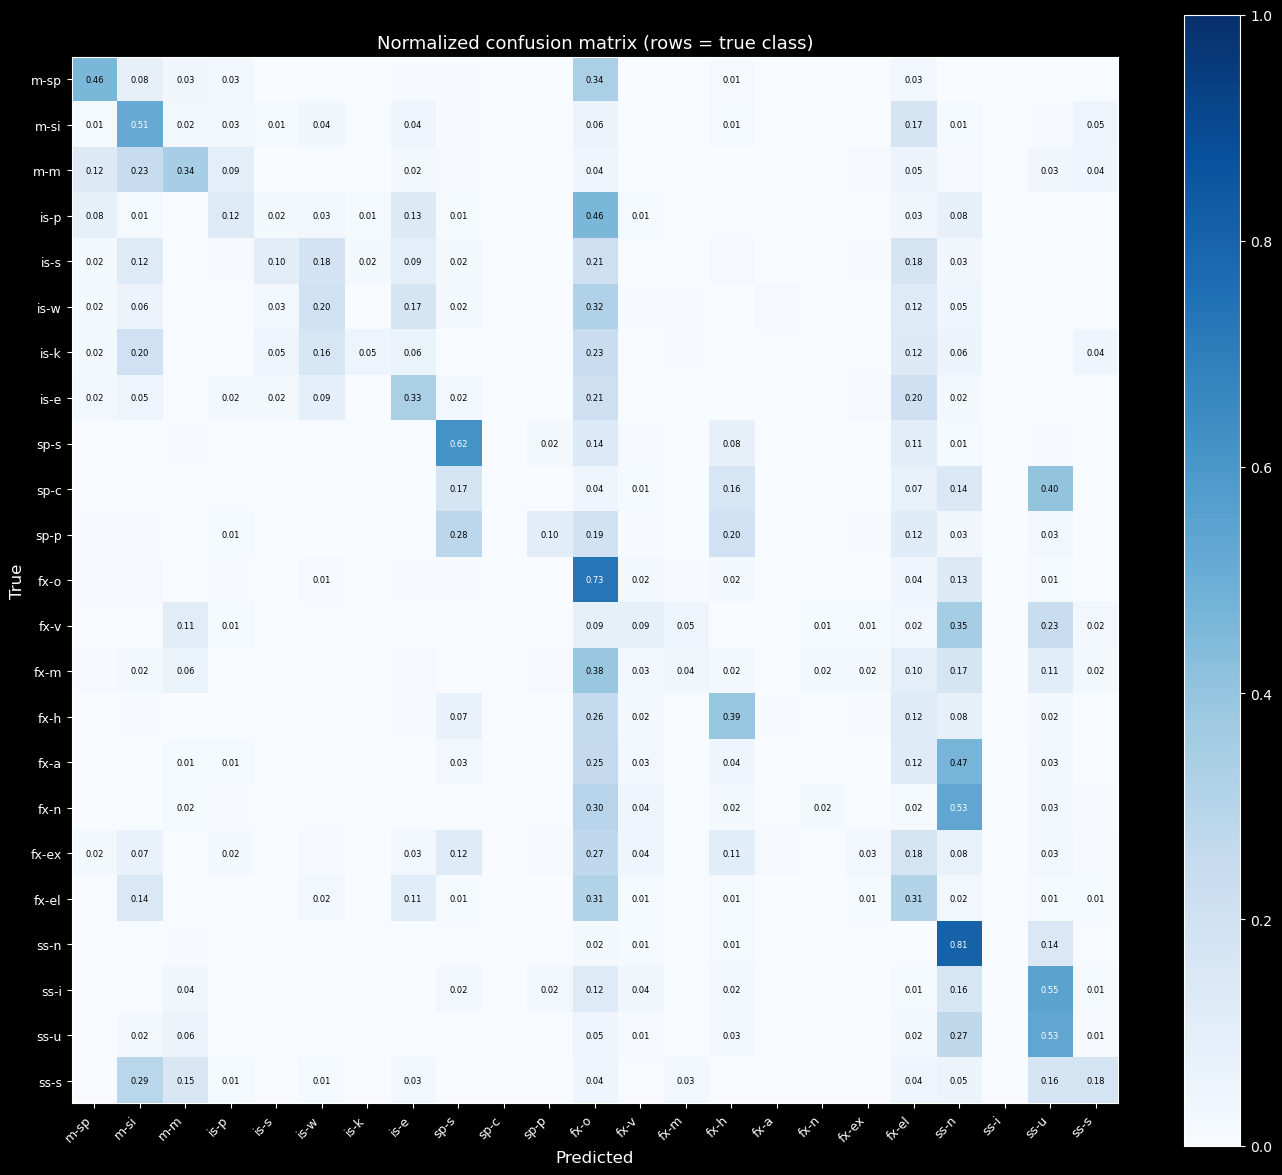

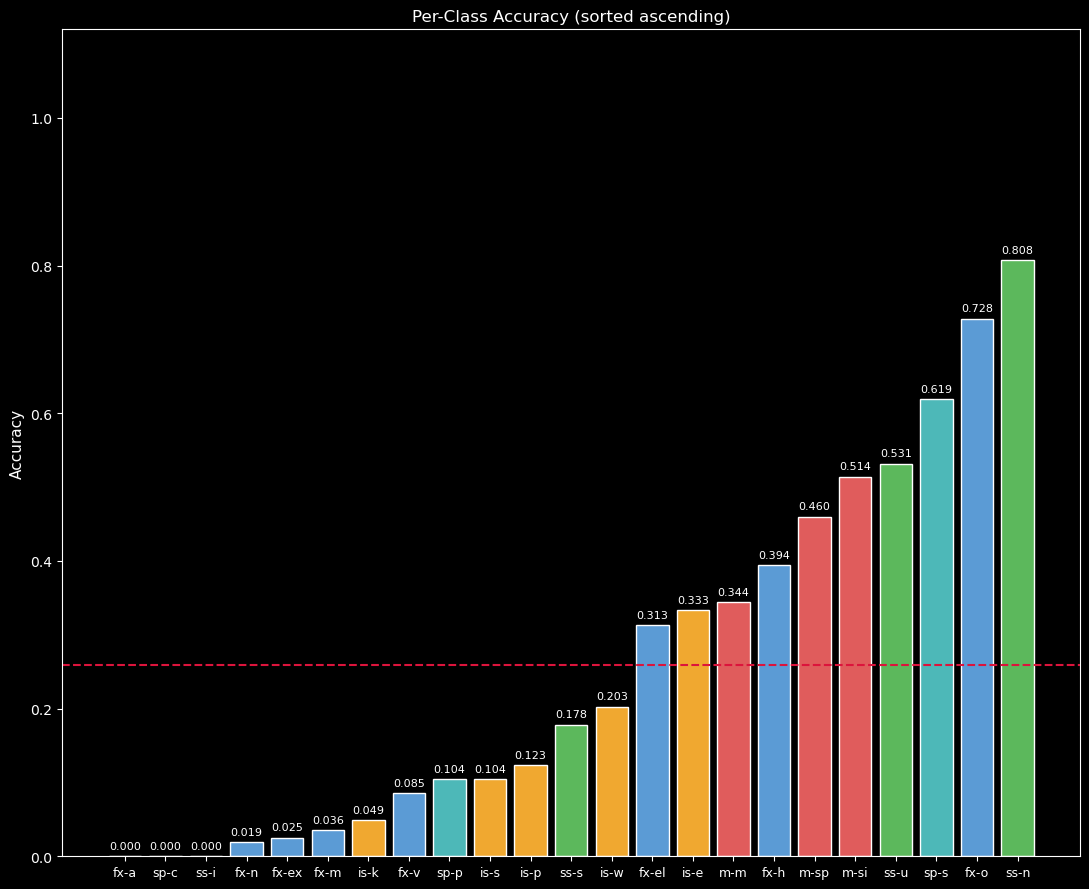

-------- TEST RESULTS --------
Overall accuracy: 0.3476 (34.76%)
Hierarchical metrics (lambda = 0.5)
  hPrecision: 0.1239 (12.39%)
  hRecall: 0.2389 (23.89%)
  hF-Score: 0.1517 (15.17%)



In [10]:
print("-------- TESTING --------")
print(f"Device: {DEVICE}")
print(f"Loading model from '{MODEL_PATH}'...")
model = AudioClassifier(num_classes=NUM_CLASSES, freeze_ast=True).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))

print("Loading test data...")
test_loader = load_test_data()
print(f"Test batches: {len(test_loader)}")

print("Running inference...")
preds, labels = get_predictions(model, test_loader)

oa = overall_accuracy(preds, labels)
pca = per_class_accuracy(preds, labels)
hp, hr, hf = hierarchical_metrics(preds, labels)

plot_confusion_matrix(preds, labels)
plot_per_class_accuracy(pca)
print("-------- TEST RESULTS --------")
print_metrics(oa, hp, hr, hf)